# HMM Post-Processing

Random Forest + Hidden Markov Model for sleep state classification.

Adding HMM post processign since RF, XGBoost, and SVM classifies each 4 second epoch independently. 
The HMM applies Viterbi decoding to the RF probability outputs using the transition structure of sleep states so it produces more realistic sequences

Uses PyEcog's `HMM_LL` class from `hmm_pyecog.py`.
 
`hmm_pyecog.py` is not written by me (Kyri) and was already within Marco's PyEcog branch.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import sys
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    balanced_accuracy_score, cohen_kappa_score, matthews_corrcoef
)
sys.path.insert(0, os.path.abspath('..'))
from pyecog2.convert_figshare_sleep_data import readbinary_dat
from pyecog2.hmm_pyecog import HMM_LL
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

CLASSES=np.array(['n', 'r', 'w'])
CLASS_NAMES = {'n': 'NREM', 'r': 'REM', 'w': 'Wake'}

Leave-one-out CV with predict_proba

In [2]:
def extract_power(power_spectra):
    bands = {
        'delta1':(0.75, 1.75),
        'delta2':(2.5, 3.5),
        'theta':(6.0, 9.0),
        'sigma':(10.0, 15.0),
        'beta_lowgamma':(18.0, 45.0)
    }
    result = {}
    for name, (lo, hi) in bands.items():
        result[name] = power_spectra[:, int(lo/0.25):int(hi/0.25)].sum(axis=1)
    return result

def load_data(dat_file):
    scores, power_spectra, eeg_var, emg_var, _ = readbinary_dat(dat_file)
    artifact_map = {'1': 'w', '2': 'n', '3':'r'}
    states = np.array([artifact_map.get(s, s) for s in scores])
    bands = extract_power(power_spectra)
    df = pd.DataFrame({'state': states, 'eeg_variance': eeg_var, 'emg_variance': emg_var, **bands})
    power_cols = ['delta1', 'delta2', 'theta', 'sigma', 'beta_lowgamma', 'eeg_variance','emg_variance']
    df[power_cols] = np.log(df[power_cols].clip(lower=1e-30))
    df['delta2_delta1_ratio'] = df['delta2']-df['delta1']
    return df[df['state'].isin(['w','n','r'])].reset_index(drop=True)

In [3]:
dat_files = sorted(glob.glob('data/M*EXP1.dat'))
mouse_dfs = {}
for dat_file in dat_files:
    mouse_id = os.path.splitext(os.path.basename(dat_file))[0]
    mouse_dfs[mouse_id] = load_data(dat_file)

In [4]:
FEATURES = ['delta1', 'delta2', 'theta', 'sigma', 'beta_lowgamma', 'eeg_variance', 'emg_variance', 'delta2_delta1_ratio']
LABEL = 'state'

In [5]:
# just so I don't have to continously run the RF model
import pickle, os

if os.path.exists('rf_results.pkl'):
    with open('rf_results.pkl', 'rb') as file:
        _saved = pickle.load(file)
    per_mouse = _saved['per_mouse']
    rf_results = _saved['rf_results']
    mouse_ids = _saved['mouse_ids']
    all_y_true_rf = _saved['all_y_true_rf']
    all_y_pred_rf = _saved['all_y_pred_rf']
    rf_results_df = pd.DataFrame(rf_results)

In [6]:
mouse_ids = list(mouse_dfs.keys())
rf_results = []
per_mouse = {}
all_y_true_rf = []
all_y_pred_rf = []

In [ ]:
for test_mouse in mouse_ids:
    train_mice = [m for m in mouse_ids if m != test_mouse]
    train_df = pd.concat([mouse_dfs[m] for m in train_mice], ignore_index=True)
    test_df  = mouse_dfs[test_mouse]

    X_train = train_df[FEATURES].values
    y_train = train_df[LABEL].values
    X_test = test_df[FEATURES].values
    y_test = test_df[LABEL].values

    clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=7)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    proba = clf.predict_proba(X_test) 

    # making sure argmax of proba matches the predictions
    assert np.all(clf.classes_[np.argmax(proba, axis=1)] == y_pred), f'argmax doesnt match prediction for {test_mouse}'
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    rf_results.append({'mouse': test_mouse, 'balanced_accuracy': bal_acc})
    all_y_true_rf.extend(y_test)
    all_y_pred_rf.extend(y_pred)

    per_mouse[test_mouse] = {
        'y_true': y_test,
        'y_pred': y_pred,
        'proba': proba,
        'classes': clf.classes_,
        'y_train': y_train, #for transition matrix
        'train_mice': train_mice
    }
    print(f'{test_mouse}: RF balanced accuracy = {bal_acc:.3f}')

M10EXP1: RF balanced accuracy = 0.835
M11EXP1: RF balanced accuracy = 0.931
M12EXP1: RF balanced accuracy = 0.931
M13EXP1: RF balanced accuracy = 0.736
M14EXP1: RF balanced accuracy = 0.876
M15EXP1: RF balanced accuracy = 0.739
M16EXP1: RF balanced accuracy = 0.811
M17EXP1: RF balanced accuracy = 0.720
M18EXP1: RF balanced accuracy = 0.716
M19EXP1: RF balanced accuracy = 0.828
M1EXP1: RF balanced accuracy = 0.912
M20EXP1: RF balanced accuracy = 0.880
M21EXP1: RF balanced accuracy = 0.691
M22EXP1: RF balanced accuracy = 0.784
M23EXP1: RF balanced accuracy = 0.828
M24EXP1: RF balanced accuracy = 0.860
M25EXP1: RF balanced accuracy = 0.743
M26EXP1: RF balanced accuracy = 0.833
M27EXP1: RF balanced accuracy = 0.901
M28EXP1: RF balanced accuracy = 0.849
M29EXP1: RF balanced accuracy = 0.554
M2EXP1: RF balanced accuracy = 0.893
M3EXP1: RF balanced accuracy = 0.872
M4EXP1: RF balanced accuracy = 0.356
M5EXP1: RF balanced accuracy = 0.887
M6EXP1: RF balanced accuracy = 0.719
M7EXP1: RF balance

In [22]:
import pickle

rf_results_df = pd.DataFrame(rf_results)

with open('rf_results.pkl', 'wb') as file:
    pickle.dump({
        'per_mouse': per_mouse,
        'rf_results': rf_results,
        'mouse_ids': mouse_ids,
        'all_y_true_rf': all_y_true_rf,
        'all_y_pred_rf': all_y_pred_rf
    }, file)

In [26]:
print(f'\nRF mean balanced accuracy: {rf_results_df["balanced_accuracy"].mean():.3f} +/- {rf_results_df["balanced_accuracy"].std():.3f}')


RF mean balanced accuracy: 0.797 +/- 0.121


In [27]:
kappa_rf = cohen_kappa_score(all_y_true_rf, all_y_pred_rf)
mcc_rf = matthews_corrcoef(all_y_true_rf, all_y_pred_rf)
print(f"Cohen's kappa: {kappa_rf:.4f}  MCC: {mcc_rf:.4f}")

Cohen's kappa: 0.7921  MCC: 0.7925


Transition Matrix Estimation

In [14]:
def estimate_transition_matrix(mouse_dfs_train, classes):
    """
    Estimating transition matrix between states
    Counts transitions within each mouse only.

    Returns A[i, j] = P(next_state=j | current_state =i).
    """
    k = len(classes)
    idx = {c: i for i, c in enumerate(classes)}
    counts = np.ones((k, k))  # Laplace smoothing to avoid zero probabilities

    for df in mouse_dfs_train:
        states = df[LABEL].values
        for t in range(len(states) - 1):
            i = idx.get(states[t],-1)
            j = idx.get(states[t + 1],-1)
            if i >= 0 and j >= 0:
                counts[i,j] += 1

    A = counts / counts.sum(axis=1, keepdims=True)
    return A

In [15]:
# Compute transition matrix for the first fold without M10EXP1
example_mouse = mouse_ids[0]
example_train_dfs = [mouse_dfs[m] for m in mouse_ids if m != example_mouse]
classes = per_mouse[example_mouse]['classes']

A_example = estimate_transition_matrix(example_train_dfs, classes)

KeyError: 'M10EXP1'

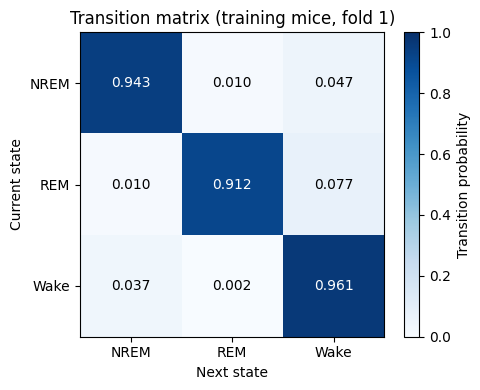

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(A_example, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Transition probability')

state_labels = [CLASS_NAMES[c] for c in classes]
ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(state_labels)
ax.set_yticklabels(state_labels)
ax.set_xlabel('Next state')
ax.set_ylabel('Current state')
ax.set_title('Transition matrix (training mice, fold 1)')

for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, f'{A_example[i, j]:.3f}', ha='center', va='center', color='white' if A_example[i, j] > 0.5 else 'black', fontsize=10)

plt.tight_layout()
plt.show()

REM has the lowest self transition, makes sense since it's the 'rarest' state

Applying Viberti decoding (using HMM_LL)

In [17]:
def apply_viterbi(proba, A, classes):
    hmm = HMM_LL()
    hmm.A = A

    # HMM_LL expects (k, N)
    log_phi = np.log(proba.T + 1e-300)  # clipping to avoid log(0)
    ml_path,_, _= hmm.viterbi(log_phi)
    return classes[ml_path[0]] # most likely sequence of sleep states

In [33]:
# Validating on one mouse first
test_mouse = example_mouse
d = per_mouse[test_mouse]

train_dfs = [mouse_dfs[m] for m in mouse_ids if m != test_mouse]
A = estimate_transition_matrix(train_dfs, d['classes'])

y_true = d['y_true']
y_rf = d['y_pred']
y_hmm = apply_viterbi(d['proba'], A, d['classes'])

bal_rf = balanced_accuracy_score(y_true, y_rf)
bal_hmm = balanced_accuracy_score(y_true, y_hmm)
kappa_rf  = cohen_kappa_score(y_true, y_rf)
kappa_hmm = cohen_kappa_score(y_true, y_hmm)

Viterbi (jit) 3 86400


In [39]:
print(f'Mouse: {test_mouse}')
print(f'{"Balanced accuracy:":} rf:{bal_rf:1.3f}  rf+hmm:{bal_hmm:1.3f}')
print(f"{'Cohens kappa:':} rf:{kappa_rf:1.3f}  rf+hmm:{kappa_hmm:1.3f}")

Mouse: M10EXP1
Balanced accuracy: rf:0.835  rf+hmm:0.850
Cohens kappa: rf:0.853  rf+hmm:0.876


In [ ]:
print('RF only:')
print(classification_report(y_true, y_rf, labels=['w','n','r'], target_names=['Wake','NREM','REM']))
print('RF + HMM:')
print(classification_report(y_true, y_hmm, labels=['w','n','r'], target_names=['Wake','NREM','REM']))

RF only:
              precision    recall  f1-score   support

        Wake       0.97      0.91      0.94     43468
        NREM       0.89      0.97      0.93     37815
         REM       0.69      0.63      0.66      5117

    accuracy                           0.92     86400
   macro avg       0.85      0.84      0.84     86400
weighted avg       0.92      0.92      0.92     86400

RF + HMM:
              precision    recall  f1-score   support

        Wake       0.99      0.91      0.95     43468
        NREM       0.88      0.99      0.93     37815
         REM       0.97      0.64      0.77      5117

    accuracy                           0.93     86400
   macro avg       0.95      0.85      0.89     86400
weighted avg       0.94      0.93      0.93     86400



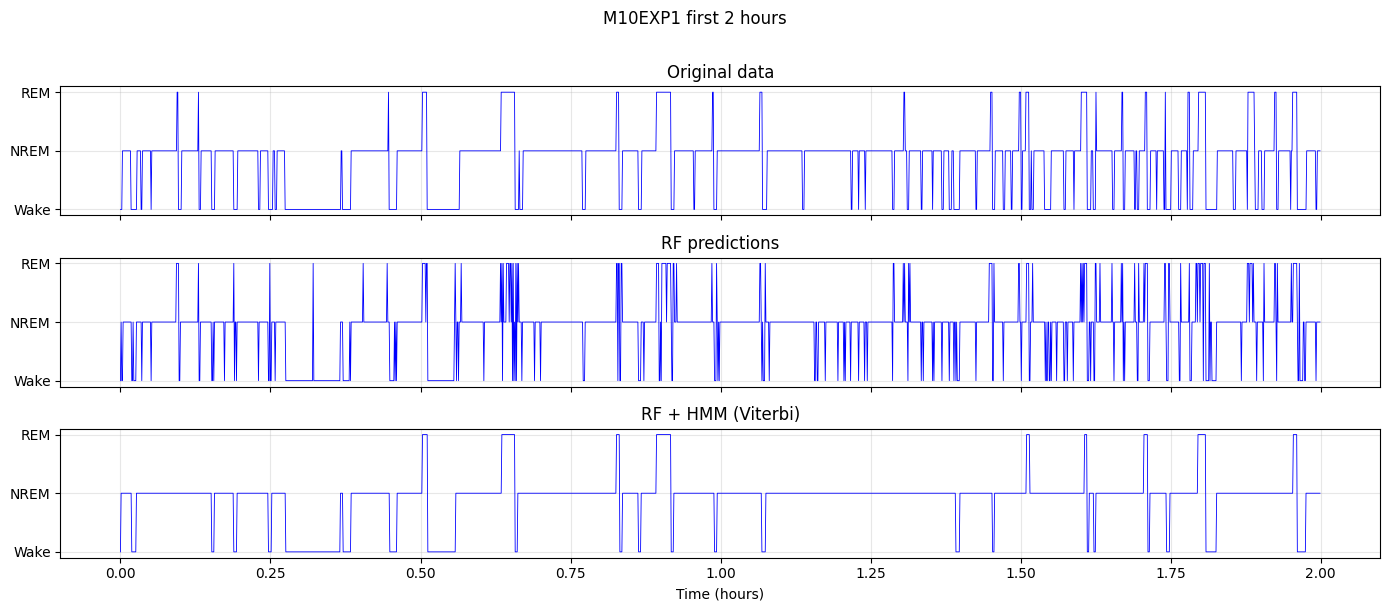

In [ ]:
# 2 hour window plot for M10EXP1 comparing True values, RF and RF + HMM
state_int = {'w': 0, 'n': 1, 'r': 2}
window = slice(0, 1800)
t_hours = np.arange(len(y_true)) * 4 / 3600
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)

for ax, labels, title in zip(
    axes,
    [y_true, y_rf, y_hmm],
    ['Original data', 'RF predictions', 'RF + HMM (Viterbi)']
):
    ax.plot(t_hours[window], [state_int[s] for s in labels[window]], linewidth=0.6, color='blue')
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['Wake', 'NREM', 'REM'])
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (hours)')
plt.suptitle(f'M10EXP1 first 2 hours', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
hmm_results = []
all_y_true_rf  = []
all_y_pred_rf  = []
all_y_pred_hmm = []

for test_mouse in mouse_ids:
    d = per_mouse[test_mouse]
    train_dfs = [mouse_dfs[m] for m in mouse_ids if m != test_mouse]

    A = estimate_transition_matrix(train_dfs, d['classes'])
    y_hmm = apply_viterbi(d['proba'], A, d['classes'])
    bal_rf=balanced_accuracy_score(d['y_true'], d['y_pred'])
    bal_hmm = balanced_accuracy_score(d['y_true'], y_hmm)

    hmm_results.append({
        'mouse': test_mouse,
        'bal_acc_rf':  bal_rf,
        'bal_acc_hmm': bal_hmm,
        'delta': bal_hmm-bal_rf
    })
    all_y_true_rf.extend(d['y_true'])
    all_y_pred_rf.extend(d['y_pred'])
    all_y_pred_hmm.extend(y_hmm)

hmm_df = pd.DataFrame(hmm_results)

Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400


In [56]:
labels = ['w', 'n', 'r']
label_names = ['Wake', 'NREM', 'REM']

print('Random Forest:')
print(classification_report(all_y_true_rf, all_y_pred_rf, labels=labels, target_names=label_names))
kappa = cohen_kappa_score(all_y_true_rf, all_y_pred_rf)
mcc= matthews_corrcoef(all_y_true_rf, all_y_pred_rf)
print(f"Cohen's kappa: {kappa:.4f}   MCC: {mcc:.4f}")

Random Forest:
              precision    recall  f1-score   support

        Wake       0.91      0.93      0.92   1421943
        NREM       0.88      0.87      0.88    948297
         REM       0.77      0.58      0.66    135360

    accuracy                           0.89   2505600
   macro avg       0.85      0.80      0.82   2505600
weighted avg       0.89      0.89      0.89   2505600

Cohen's kappa: 0.7921   MCC: 0.7925


In [57]:
print('Random Forest + HMM:')
print(classification_report(all_y_true_rf, all_y_pred_hmm, labels=labels, target_names=label_names))
kappa = cohen_kappa_score(all_y_true_rf, all_y_pred_hmm)
mcc   = matthews_corrcoef(all_y_true_rf, all_y_pred_hmm)
print(f"Cohen's kappa: {kappa:.4f}   MCC: {mcc:.4f}")

Random Forest + HMM:
              precision    recall  f1-score   support

        Wake       0.92      0.95      0.93   1421943
        NREM       0.90      0.90      0.90    948297
         REM       0.95      0.56      0.71    135360

    accuracy                           0.91   2505600
   macro avg       0.92      0.80      0.85   2505600
weighted avg       0.91      0.91      0.91   2505600

Cohen's kappa: 0.8300   MCC: 0.8309


In [51]:
print(f"Random forest + HMM mean balanced accuracy: {hmm_df['bal_acc_hmm'].mean():.3f} +/- {hmm_df['bal_acc_hmm'].std():.3f}")

Random forest + HMM mean balanced accuracy: 0.806 +/- 0.139


In [50]:
print(f"Random Forest mean balanced accuracy: {hmm_df['bal_acc_rf'].mean():.3f} +/- {hmm_df['bal_acc_rf'].std():.3f}")

Random Forest mean balanced accuracy: 0.797 +/- 0.121


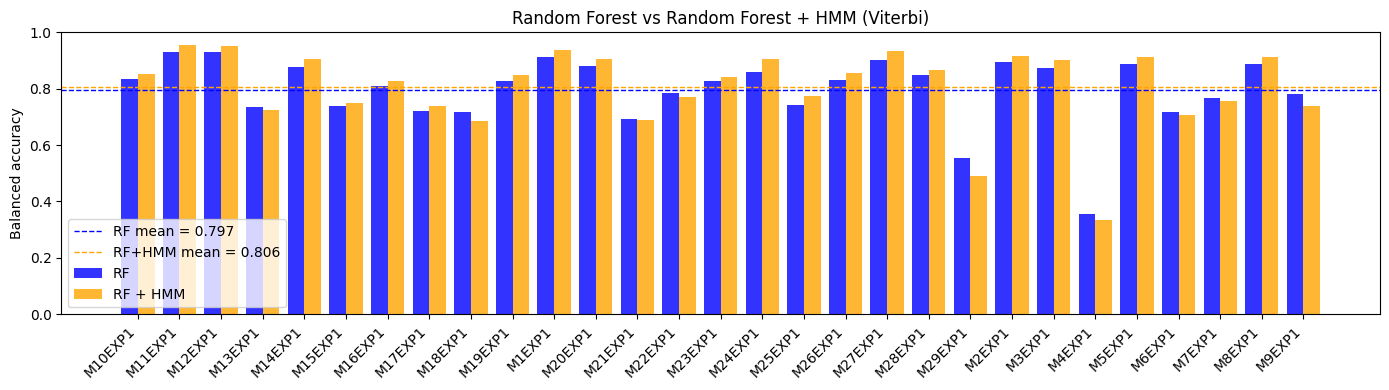

In [ ]:
# Per-mouse balanced accuracy: RF vs RF+HMM
fig, ax = plt.subplots(figsize=(14, 4))
x = np.arange(len(hmm_df))
width = 0.4
ax.bar(x-width/2, hmm_df['bal_acc_rf'],  width, label='RF', color='blue', alpha=0.8)
ax.bar(x+width/2, hmm_df['bal_acc_hmm'], width, label='RF + HMM', color='orange', alpha=0.8)

ax.axhline(hmm_df['bal_acc_rf'].mean(), color='blue', linestyle='--', linewidth=1, label=f'RF mean = {hmm_df["bal_acc_rf"].mean():.3f}')
ax.axhline(hmm_df['bal_acc_hmm'].mean(), color='orange', linestyle='--', linewidth=1, label=f'RF+HMM mean = {hmm_df["bal_acc_hmm"].mean():.3f}')

ax.set_xticks(x)
ax.set_xticklabels(hmm_df['mouse'], rotation=45, ha='right')
ax.set_ylabel('Balanced accuracy')
ax.set_title('Random Forest vs Random Forest + HMM (Viterbi)')
ax.set_ylim(0,1)
ax.legend()
plt.tight_layout()
plt.show()

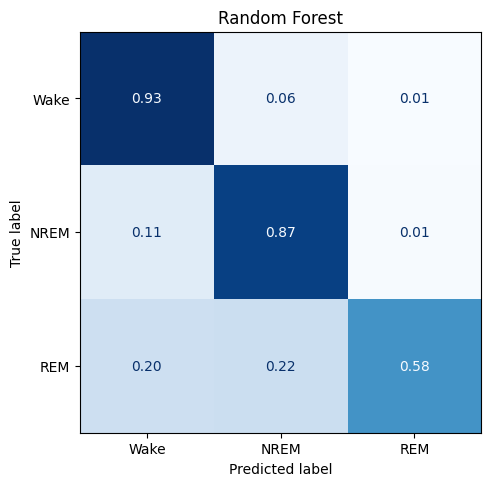

In [66]:
cm = confusion_matrix(all_y_true_rf, all_y_pred_rf, labels=labels, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
ax.set_title('Random Forest')
plt.tight_layout()
plt.show()

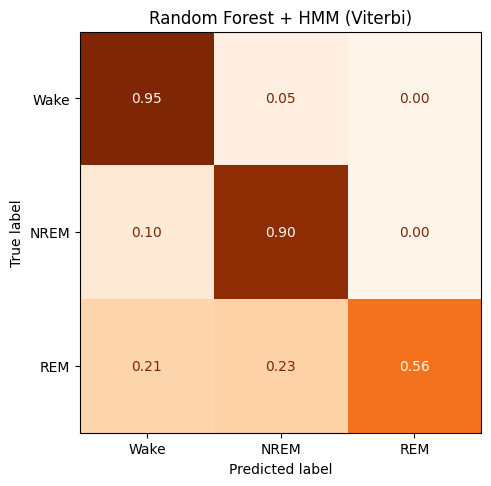

In [67]:
cm = confusion_matrix(all_y_true_rf, all_y_pred_hmm, labels=labels, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, colorbar=False, cmap='Oranges', values_format='.2f')
ax.set_title('Random Forest + HMM (Viterbi)')
plt.tight_layout()
plt.show()


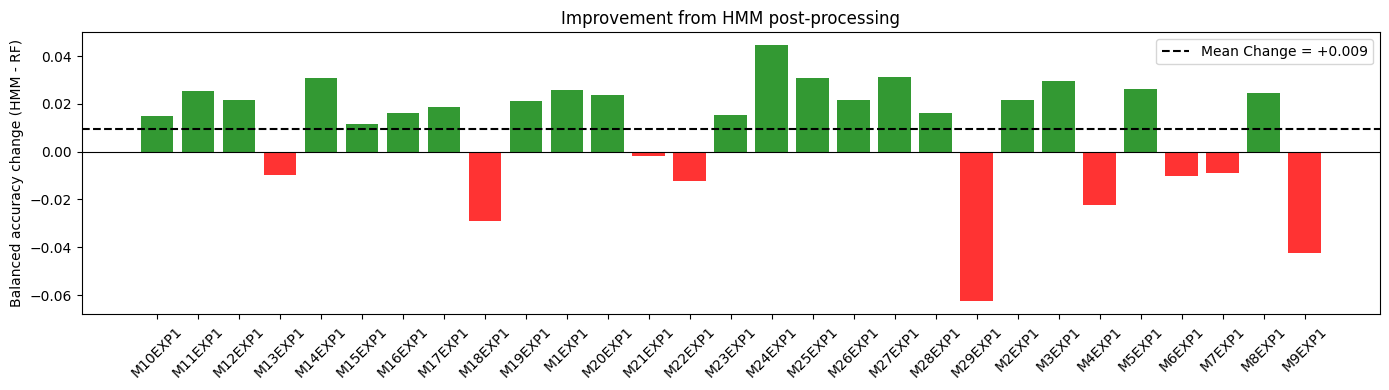

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
colors = ['green' if d > 0 else 'red' for d in hmm_df['delta']]
ax.bar(hmm_df['mouse'], hmm_df['delta'], color=colors, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(hmm_df['delta'].mean(), color='black', linestyle='--', label=f'Mean Change = {hmm_df["delta"].mean():+.3f}')
ax.set_ylabel('Balanced accuracy change (HMM - RF)')
ax.set_title('Improvement from HMM post-processing')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## XGBoost + HMM Post-Processing

Applying the same Viterbi HMM post-processing to XGBoost.

In [7]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

In [ ]:
xgb_per_mouse = {}
xgb_results = []

In [ ]:
for test_mouse in mouse_ids:
    train_mice = [m for m in mouse_ids if m != test_mouse]
    train_df = pd.concat([mouse_dfs[m] for m in train_mice], ignore_index=True)
    test_df  = mouse_dfs[test_mouse]

    X_train = train_df[FEATURES].values
    y_train = train_df[LABEL].values
    X_test  = test_df[FEATURES].values
    y_test  = test_df[LABEL].values

    le = LabelEncoder()
    le.fit(y_train)
    y_train_enc = le.transform(y_train)
    sample_weights = compute_sample_weight('balanced', y_train)

    clf = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=7,
        eval_metric='mlogloss'
    )
    clf.fit(X_train, y_train_enc, sample_weight=sample_weights)

    proba = clf.predict_proba(X_test)
    y_pred_enc = le.classes_[proba.argmax(axis=1)]
    y_pred = y_pred_enc

    bal_acc = balanced_accuracy_score(y_test, y_pred)
    xgb_results.append({'mouse': test_mouse, 'balanced_accuracy': bal_acc})

    xgb_per_mouse[test_mouse] = {
        'y_true': y_test,
        'y_pred': y_pred,
        'proba':proba,
        'classes': le.classes_,
        'y_train': y_train,
    }
    print(f'{test_mouse}: XGBoost balanced accuracy = {bal_acc:.3f}')

M10EXP1: XGBoost balanced accuracy = 0.897
M11EXP1: XGBoost balanced accuracy = 0.875
M12EXP1: XGBoost balanced accuracy = 0.924
M13EXP1: XGBoost balanced accuracy = 0.812
M14EXP1: XGBoost balanced accuracy = 0.905
M15EXP1: XGBoost balanced accuracy = 0.824
M16EXP1: XGBoost balanced accuracy = 0.889
M17EXP1: XGBoost balanced accuracy = 0.820
M18EXP1: XGBoost balanced accuracy = 0.795
M19EXP1: XGBoost balanced accuracy = 0.863
M1EXP1: XGBoost balanced accuracy = 0.920
M20EXP1: XGBoost balanced accuracy = 0.893
M21EXP1: XGBoost balanced accuracy = 0.784
M22EXP1: XGBoost balanced accuracy = 0.848
M23EXP1: XGBoost balanced accuracy = 0.873
M24EXP1: XGBoost balanced accuracy = 0.879
M25EXP1: XGBoost balanced accuracy = 0.727
M26EXP1: XGBoost balanced accuracy = 0.904
M27EXP1: XGBoost balanced accuracy = 0.905
M28EXP1: XGBoost balanced accuracy = 0.898
M29EXP1: XGBoost balanced accuracy = 0.691
M2EXP1: XGBoost balanced accuracy = 0.922
M3EXP1: XGBoost balanced accuracy = 0.927
M4EXP1: XGBoos

In [10]:
xgb_results_df = pd.DataFrame(xgb_results)
print(f'\nXGBoost mean balanced accuracy: {xgb_results_df["balanced_accuracy"].mean():.3f} +/- {xgb_results_df["balanced_accuracy"].std():.3f}')


XGBoost mean balanced accuracy: 0.849 +/- 0.110


In [ ]:
xgb_hmm_results = []
all_y_true_xgb  = []
all_y_pred_xgb  = []
all_y_pred_xgb_hmm = []

for test_mouse in mouse_ids:
    d = xgb_per_mouse[test_mouse]
    train_dfs = [mouse_dfs[m] for m in mouse_ids if m != test_mouse]

    A = estimate_transition_matrix(train_dfs, d['classes'])
    y_hmm = apply_viterbi(d['proba'], A, d['classes'])

    bal_xgb  = balanced_accuracy_score(d['y_true'], d['y_pred'])
    bal_hmm  = balanced_accuracy_score(d['y_true'], y_hmm)

    xgb_hmm_results.append({
        'mouse': test_mouse,
        'bal_acc_xgb': bal_xgb,
        'bal_acc_hmm': bal_hmm,
        'delta': bal_hmm - bal_xgb
    })
    all_y_true_xgb.extend(d['y_true'])
    all_y_pred_xgb.extend(d['y_pred'])
    all_y_pred_xgb_hmm.extend(y_hmm)

xgb_hmm_df = pd.DataFrame(xgb_hmm_results)
print(f"XGBoost mean balanced accuracy: {xgb_hmm_df['bal_acc_xgb'].mean():.3f} +/- {xgb_hmm_df['bal_acc_xgb'].std():.3f}")
print(f"XGBoost + HMM mean balanced accuracy: {xgb_hmm_df['bal_acc_hmm'].mean():.3f} +/- {xgb_hmm_df['bal_acc_hmm'].std():.3f}")

Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
Viterbi (jit) 3 86400
XGBoost mean balanced accuracy:         0.849 +/- 0.110
XGBoost + HMM mean balanced accuracy:   0.894 +/- 0.127


In [20]:
labels = ['w', 'n', 'r']
label_names = ['Wake', 'NREM', 'REM']

In [21]:
print('XGBoost:')
print(classification_report(all_y_true_xgb, all_y_pred_xgb, labels=labels, target_names=label_names))
kappa = cohen_kappa_score(all_y_true_xgb, all_y_pred_xgb)
mcc = matthews_corrcoef(all_y_true_xgb, all_y_pred_xgb)
print(f"Cohen's kappa: {kappa:.4f} MCC: {mcc:.4f}")

XGBoost:
              precision    recall  f1-score   support

        Wake       0.93      0.88      0.90   1421943
        NREM       0.89      0.84      0.86    948297
         REM       0.43      0.82      0.57    135360

    accuracy                           0.86   2505600
   macro avg       0.75      0.85      0.78   2505600
weighted avg       0.89      0.86      0.87   2505600

Cohen's kappa: 0.7517 MCC: 0.7545


In [22]:
print('\nXGBoost + HMM:')
print(classification_report(all_y_true_xgb, all_y_pred_xgb_hmm, labels=labels, target_names=label_names))
kappa = cohen_kappa_score(all_y_true_xgb, all_y_pred_xgb_hmm)
mcc = matthews_corrcoef(all_y_true_xgb, all_y_pred_xgb_hmm)
print(f"Cohen's kappa: {kappa:.4f} MCC: {mcc:.4f}")


XGBoost + HMM:
              precision    recall  f1-score   support

        Wake       0.94      0.93      0.94   1421943
        NREM       0.92      0.90      0.91    948297
         REM       0.71      0.84      0.77    135360

    accuracy                           0.92   2505600
   macro avg       0.85      0.89      0.87   2505600
weighted avg       0.92      0.92      0.92   2505600

Cohen's kappa: 0.8433 MCC: 0.8435


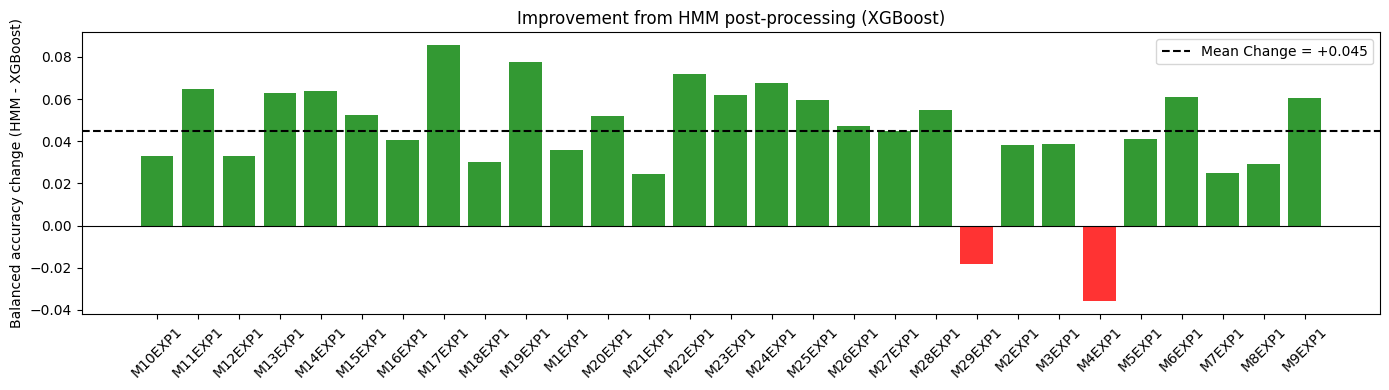

In [28]:
fig, ax = plt.subplots(figsize=(14, 4))
colors = ['green' if d > 0 else 'red' for d in xgb_hmm_df['delta']]
ax.bar(xgb_hmm_df['mouse'], xgb_hmm_df['delta'], color=colors, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(xgb_hmm_df['delta'].mean(), color='black', linestyle='--', label=f'Mean Change = {xgb_hmm_df["delta"].mean():+.3f}')
ax.set_ylabel('Balanced accuracy change (HMM - XGBoost)')
ax.set_title('Improvement from HMM post-processing (XGBoost)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

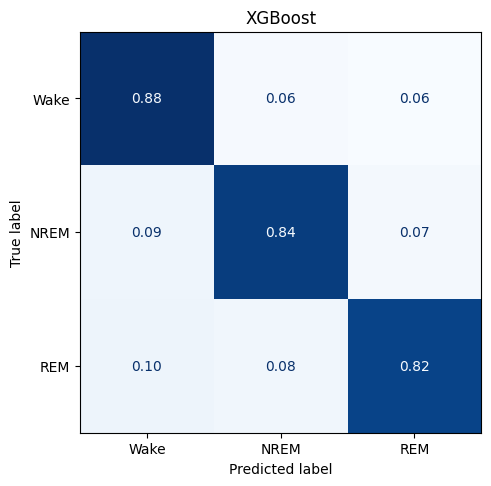

In [26]:
cm = confusion_matrix(all_y_true_xgb, all_y_pred_xgb, labels=labels, normalize='true')
disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
ax.set_title('XGBoost')
plt.tight_layout()
plt.show()

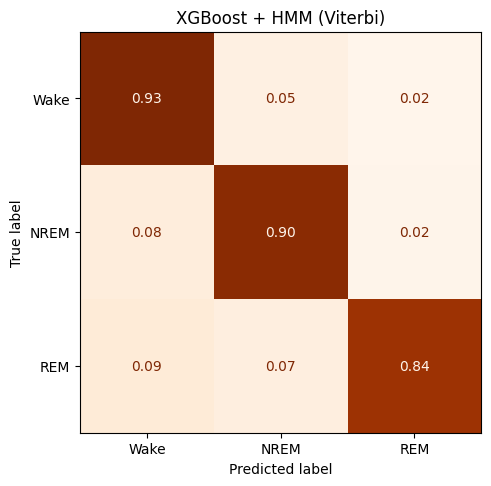

In [27]:
cm = confusion_matrix(all_y_true_xgb, all_y_pred_xgb_hmm, labels=labels, normalize='true')
disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, colorbar=False, cmap='Oranges', values_format='.2f')
ax.set_title('XGBoost + HMM (Viterbi)')
plt.tight_layout()
plt.show()